# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Dhaka Air Quality Dataset](https://www.kaggle.com/datasets/nasiruddin123/dhaka-air-quality-index-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('dhaka_air_quality_no_pollutants.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,area,station_type,aqi,aqi_category,temperature_c,humidity_pct,wind_speed_kmh,wind_direction,rainfall_mm,pressure_hpa,visibility_km,traffic_level,construction_nearby
0,Mirpur,residential,199,Unhealthy,24.0,65,3.2,W,0.0,1011.6,6.6,High,No
1,Jatrabari,industrial,114,Unhealthy for Sensitive Groups,33.2,100,3.8,S,0.0,1000.0,9.4,Severe,Yes
2,Motijheel,roadside,89,Moderate,30.6,83,8.3,E,11.5,1002.9,11.5,High,Yes
3,Mohammadpur,residential,181,Unhealthy,14.7,66,4.9,E,0.0,1009.2,7.0,Severe,No
4,Mohammadpur,residential,178,Unhealthy,25.2,53,6.9,N,0.0,1018.7,8.8,Low,No


## last Five row

In [4]:
df.tail()

,area,station_type,aqi,aqi_category,temperature_c,humidity_pct,wind_speed_kmh,wind_direction,rainfall_mm,pressure_hpa,visibility_km,traffic_level,construction_nearby
9995,Mohammadpur,residential,145,Unhealthy for Sensitive Groups,28.2,85,5.0,W,0.0,1006.9,8.4,Medium,No
9996,Hazaribagh,industrial,128,Unhealthy for Sensitive Groups,29.6,87,1.4,W,1.5,1003.9,10.2,High,No
9997,Dhanmondi,roadside,278,Very Unhealthy,23.6,78,1.4,NW,0.0,1010.4,3.7,Severe,Yes
9998,Tejgaon,industrial,233,Very Unhealthy,28.8,77,3.4,NW,0.0,1007.2,5.4,Medium,Yes
9999,Motijheel,roadside,199,Unhealthy,25.9,70,2.0,NE,3.9,1009.1,5.9,Severe,No


## Shape of our dataset

In [5]:
df.shape

(10000, 13)

## List out all columns

In [6]:
df.columns

Index(['area', 'station_type', 'aqi', 'aqi_category', 'temperature_c',
       'humidity_pct', 'wind_speed_kmh', 'wind_direction', 'rainfall_mm',
       'pressure_hpa', 'visibility_km', 'traffic_level',
       'construction_nearby'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

area                    object
station_type            object
aqi                      int64
aqi_category            object
temperature_c          float64
humidity_pct             int64
wind_speed_kmh         float64
wind_direction          object
rainfall_mm            float64
pressure_hpa           float64
visibility_km          float64
traffic_level           object
construction_nearby     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   area                 10000 non-null  object 
 1   station_type         10000 non-null  object 
 2   aqi                  10000 non-null  int64  
 3   aqi_category         10000 non-null  object 
 4   temperature_c        10000 non-null  float64
 5   humidity_pct         10000 non-null  int64  
 6   wind_speed_kmh       10000 non-null  float64
 7   wind_direction       10000 non-null  object 
 8   rainfall_mm          10000 non-null  float64
 9   pressure_hpa         10000 non-null  float64
 10  visibility_km        10000 non-null  float64
 11  traffic_level        10000 non-null  object 
 12  construction_nearby  10000 non-null  object 
dtypes: float64(5), int64(2), object(6)
memory usage: 1015.8+ KB


## Check Null Value

In [9]:
df.isnull().sum()

area                   0
station_type           0
aqi                    0
aqi_category           0
temperature_c          0
humidity_pct           0
wind_speed_kmh         0
wind_direction         0
rainfall_mm            0
pressure_hpa           0
visibility_km          0
traffic_level          0
construction_nearby    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,aqi,temperature_c,humidity_pct,wind_speed_kmh,rainfall_mm,pressure_hpa,visibility_km
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,161.342300,26.420030,75.860600,7.031910,2.061190,1008.603470,8.064830
std,78.105783,5.606521,10.556482,4.928873,6.427811,5.776719,2.319657
min,22.000000,6.500000,41.000000,0.300000,0.000000,993.500000,0.300000
25%,103.000000,22.300000,68.000000,3.500000,0.000000,1003.800000,6.900000
50%,159.000000,28.200000,76.000000,5.900000,0.000000,1008.800000,8.600000
75%,191.000000,30.600000,83.000000,9.400000,0.000000,1013.500000,9.700000
max,500.000000,39.300000,100.000000,39.700000,85.800000,1023.300000,12.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

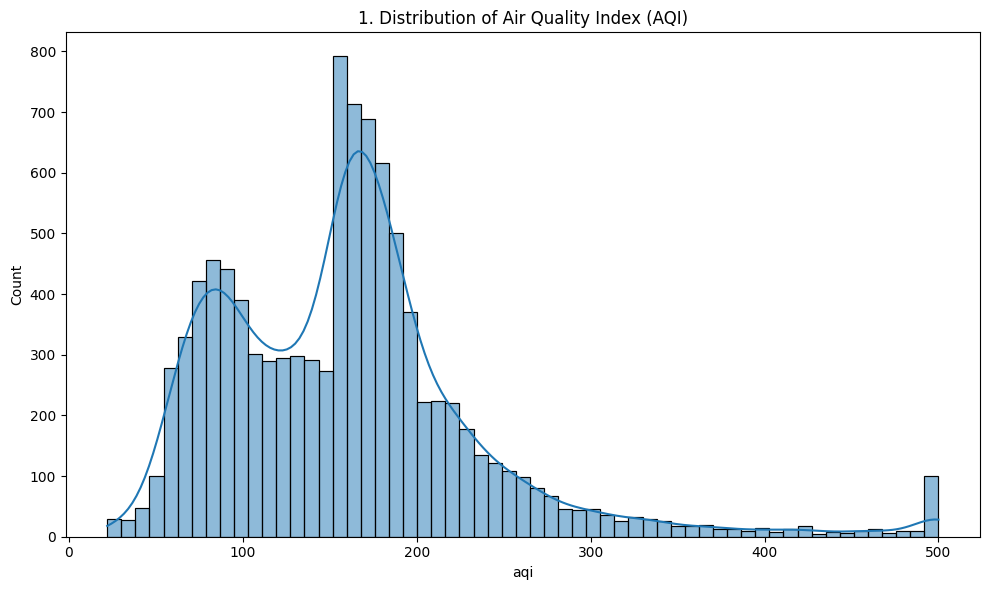

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='aqi', kde=True)
plt.title(f'{plot_no}. Distribution of Air Quality Index (AQI)')
show_fig()
plot_no += 1

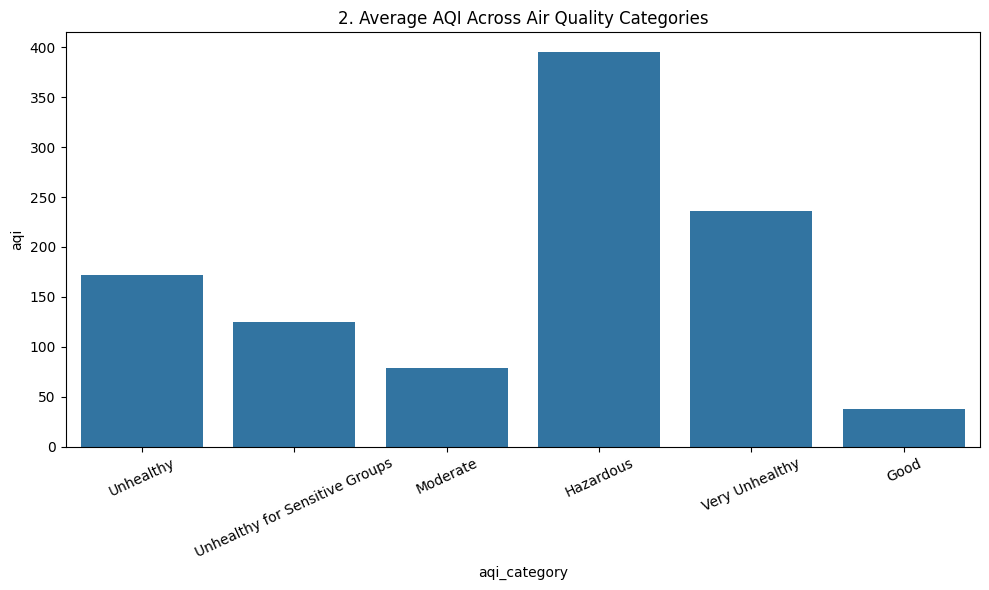

In [14]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='aqi_category', y='aqi', estimator='mean', errorbar=None)
plt.xticks(rotation=25)
plt.title(f'{plot_no}. Average AQI Across Air Quality Categories')
show_fig()
plot_no += 1

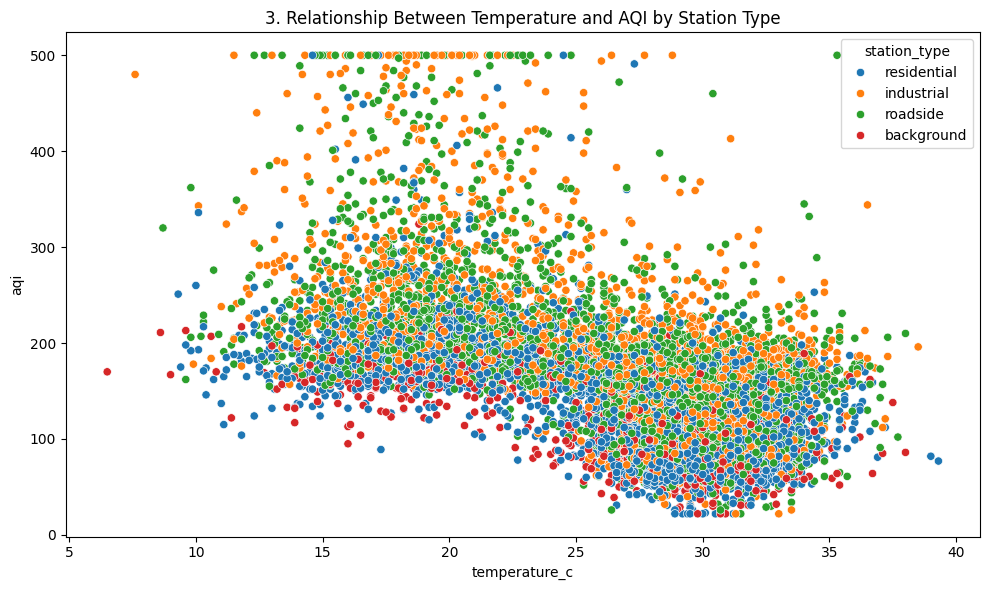

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature_c', y='aqi', hue='station_type')
plt.title(f'{plot_no}. Relationship Between Temperature and AQI by Station Type')
show_fig()
plot_no += 1

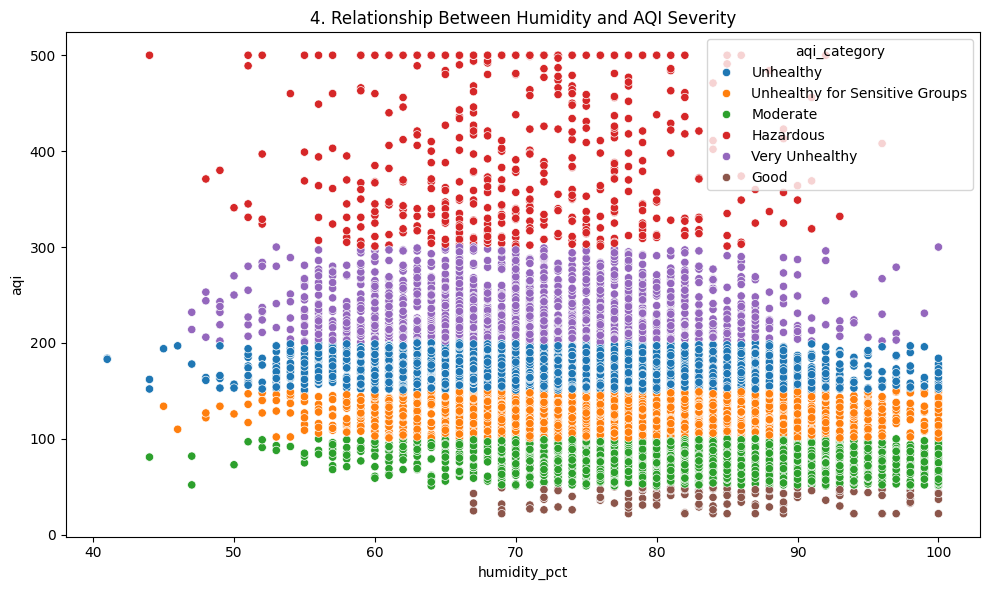

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='humidity_pct', y='aqi', hue='aqi_category')
plt.title(f'{plot_no}. Relationship Between Humidity and AQI Severity')
show_fig()
plot_no += 1

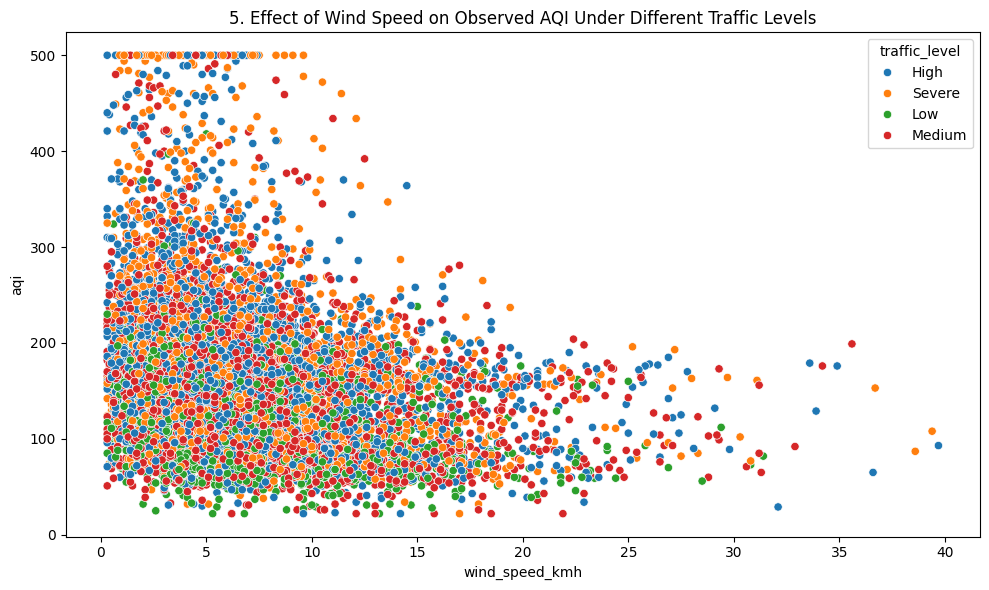

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='wind_speed_kmh', y='aqi', hue='traffic_level')
plt.title(f'{plot_no}. Effect of Wind Speed on Observed AQI Under Different Traffic Levels')
show_fig()
plot_no += 1

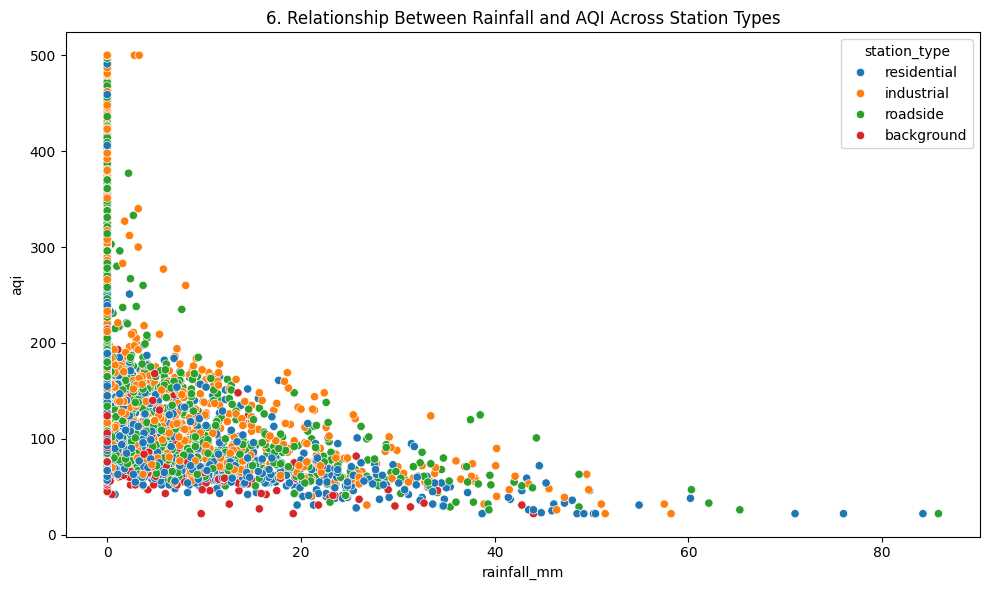

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='rainfall_mm', y='aqi', hue='station_type')
plt.title(f'{plot_no}. Relationship Between Rainfall and AQI Across Station Types')
show_fig()
plot_no += 1

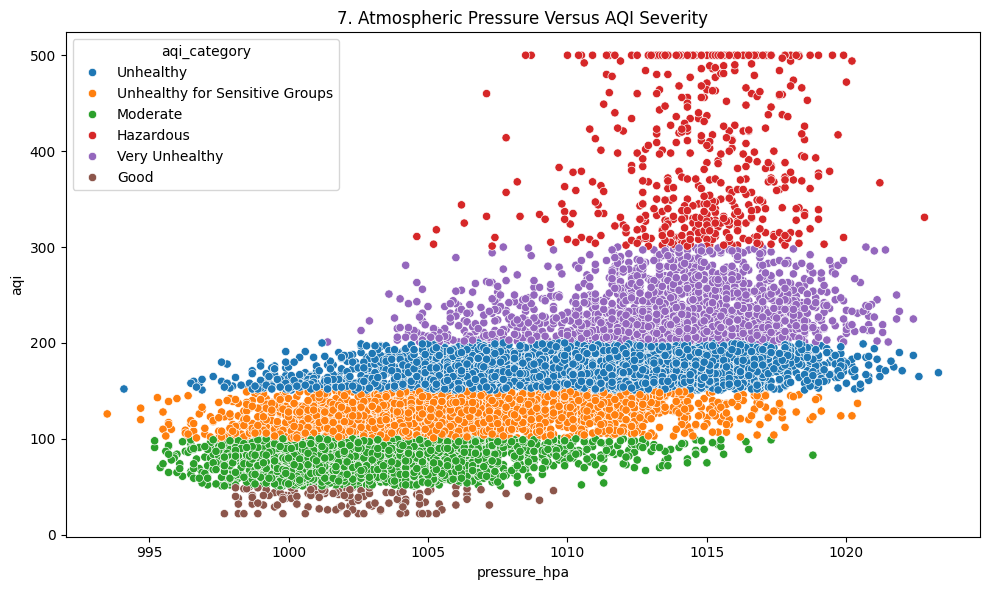

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='pressure_hpa', y='aqi', hue='aqi_category')
plt.title(f'{plot_no}. Atmospheric Pressure Versus AQI Severity')
show_fig()
plot_no += 1

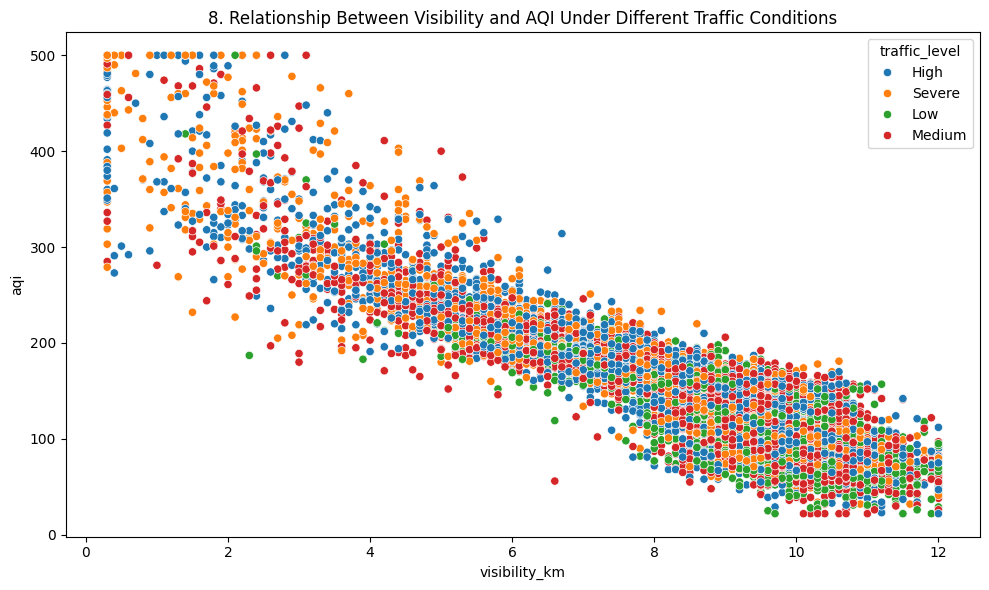

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='visibility_km', y='aqi', hue='traffic_level')
plt.title(f'{plot_no}. Relationship Between Visibility and AQI Under Different Traffic Conditions')
show_fig()
plot_no += 1

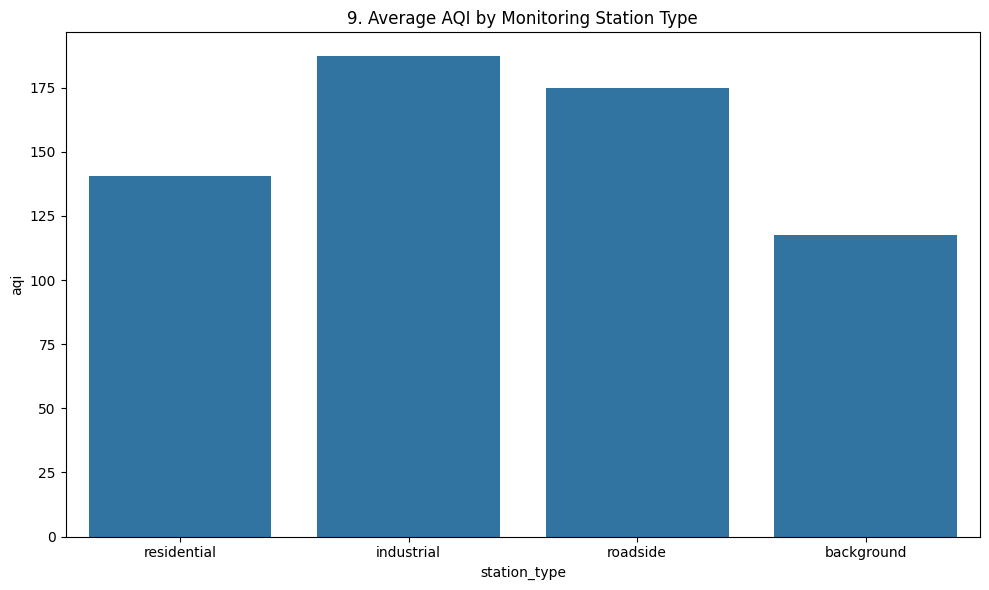

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='station_type', y='aqi', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average AQI by Monitoring Station Type')
show_fig()
plot_no += 1

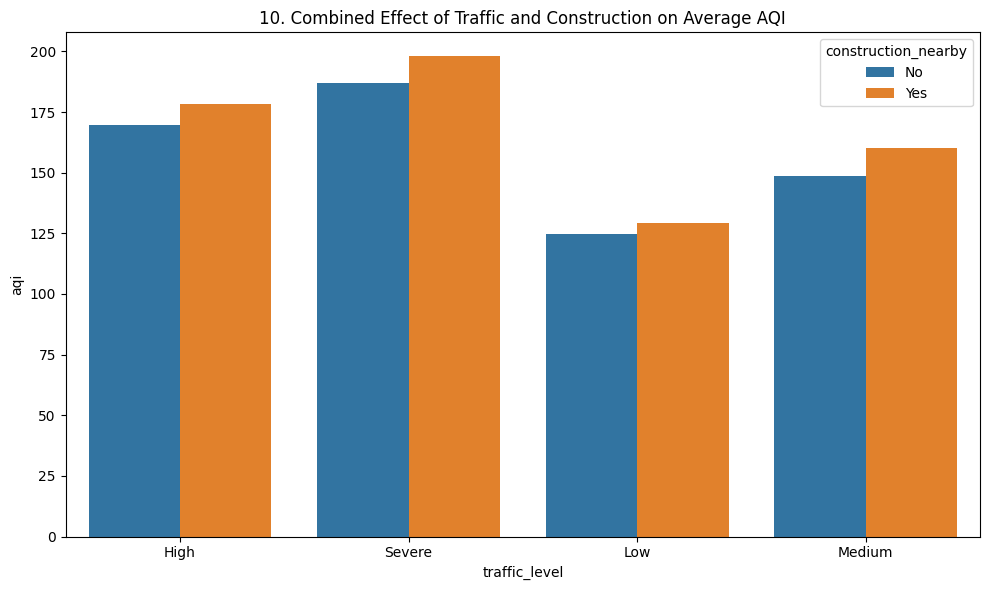

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='traffic_level', y='aqi', hue='construction_nearby', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Combined Effect of Traffic and Construction on Average AQI')
show_fig()
plot_no += 1

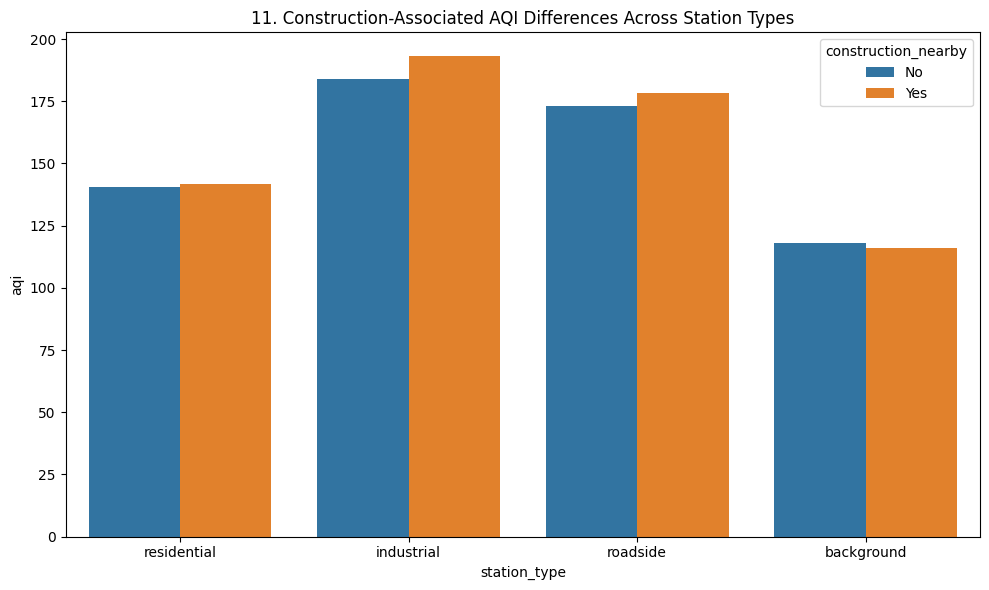

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='station_type', y='aqi', hue='construction_nearby', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Construction-Associated AQI Differences Across Station Types')
show_fig()
plot_no += 1

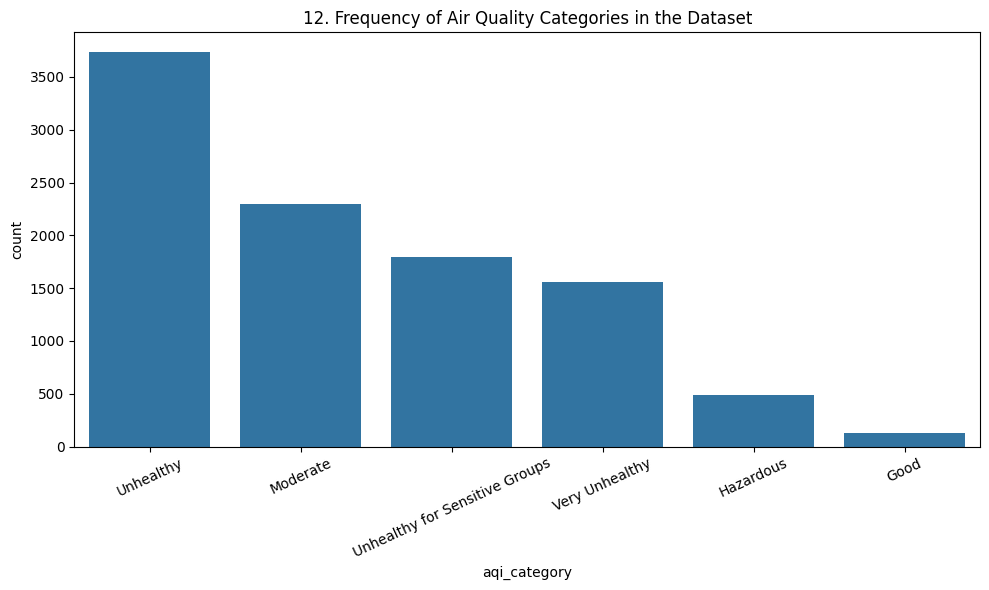

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='aqi_category', order=df['aqi_category'].value_counts().index)
plt.xticks(rotation=25)
plt.title(f'{plot_no}. Frequency of Air Quality Categories in the Dataset')
show_fig()
plot_no += 1

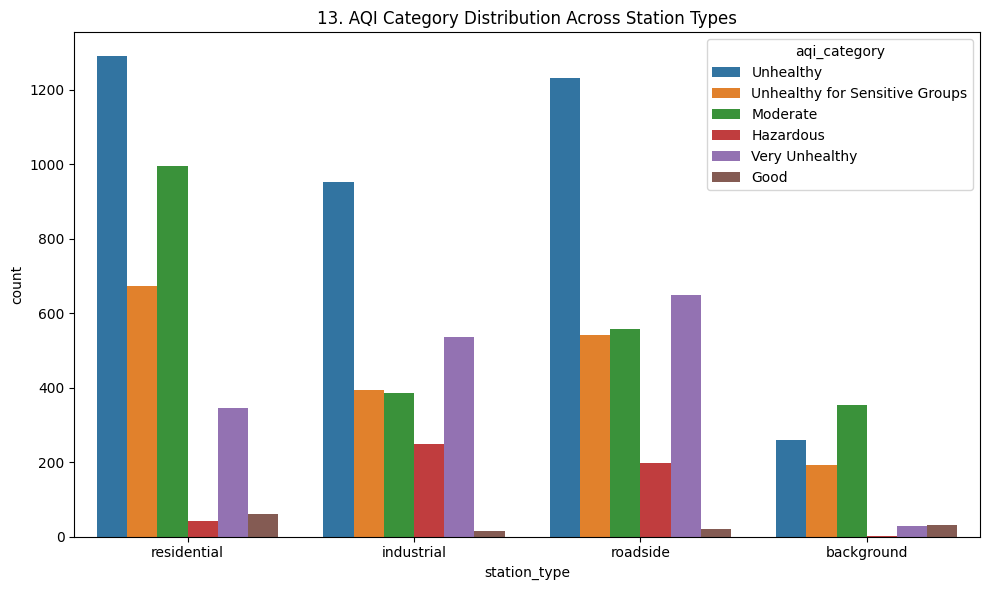

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='station_type', hue='aqi_category')
plt.title(f'{plot_no}. AQI Category Distribution Across Station Types')
show_fig()
plot_no += 1

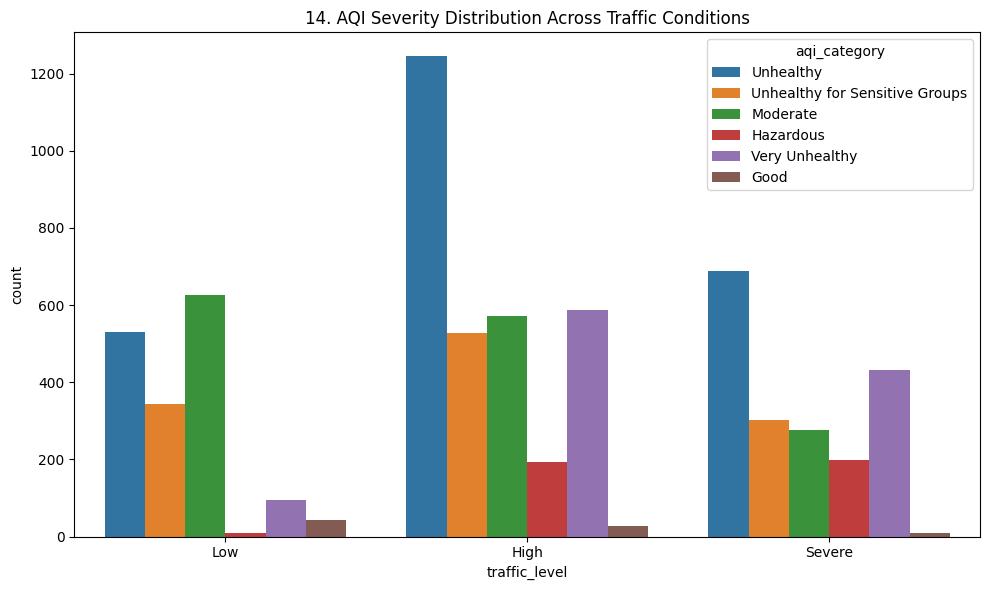

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='traffic_level', hue='aqi_category', order=['Low', 'High', 'Severe'])
plt.title(f'{plot_no}. AQI Severity Distribution Across Traffic Conditions')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

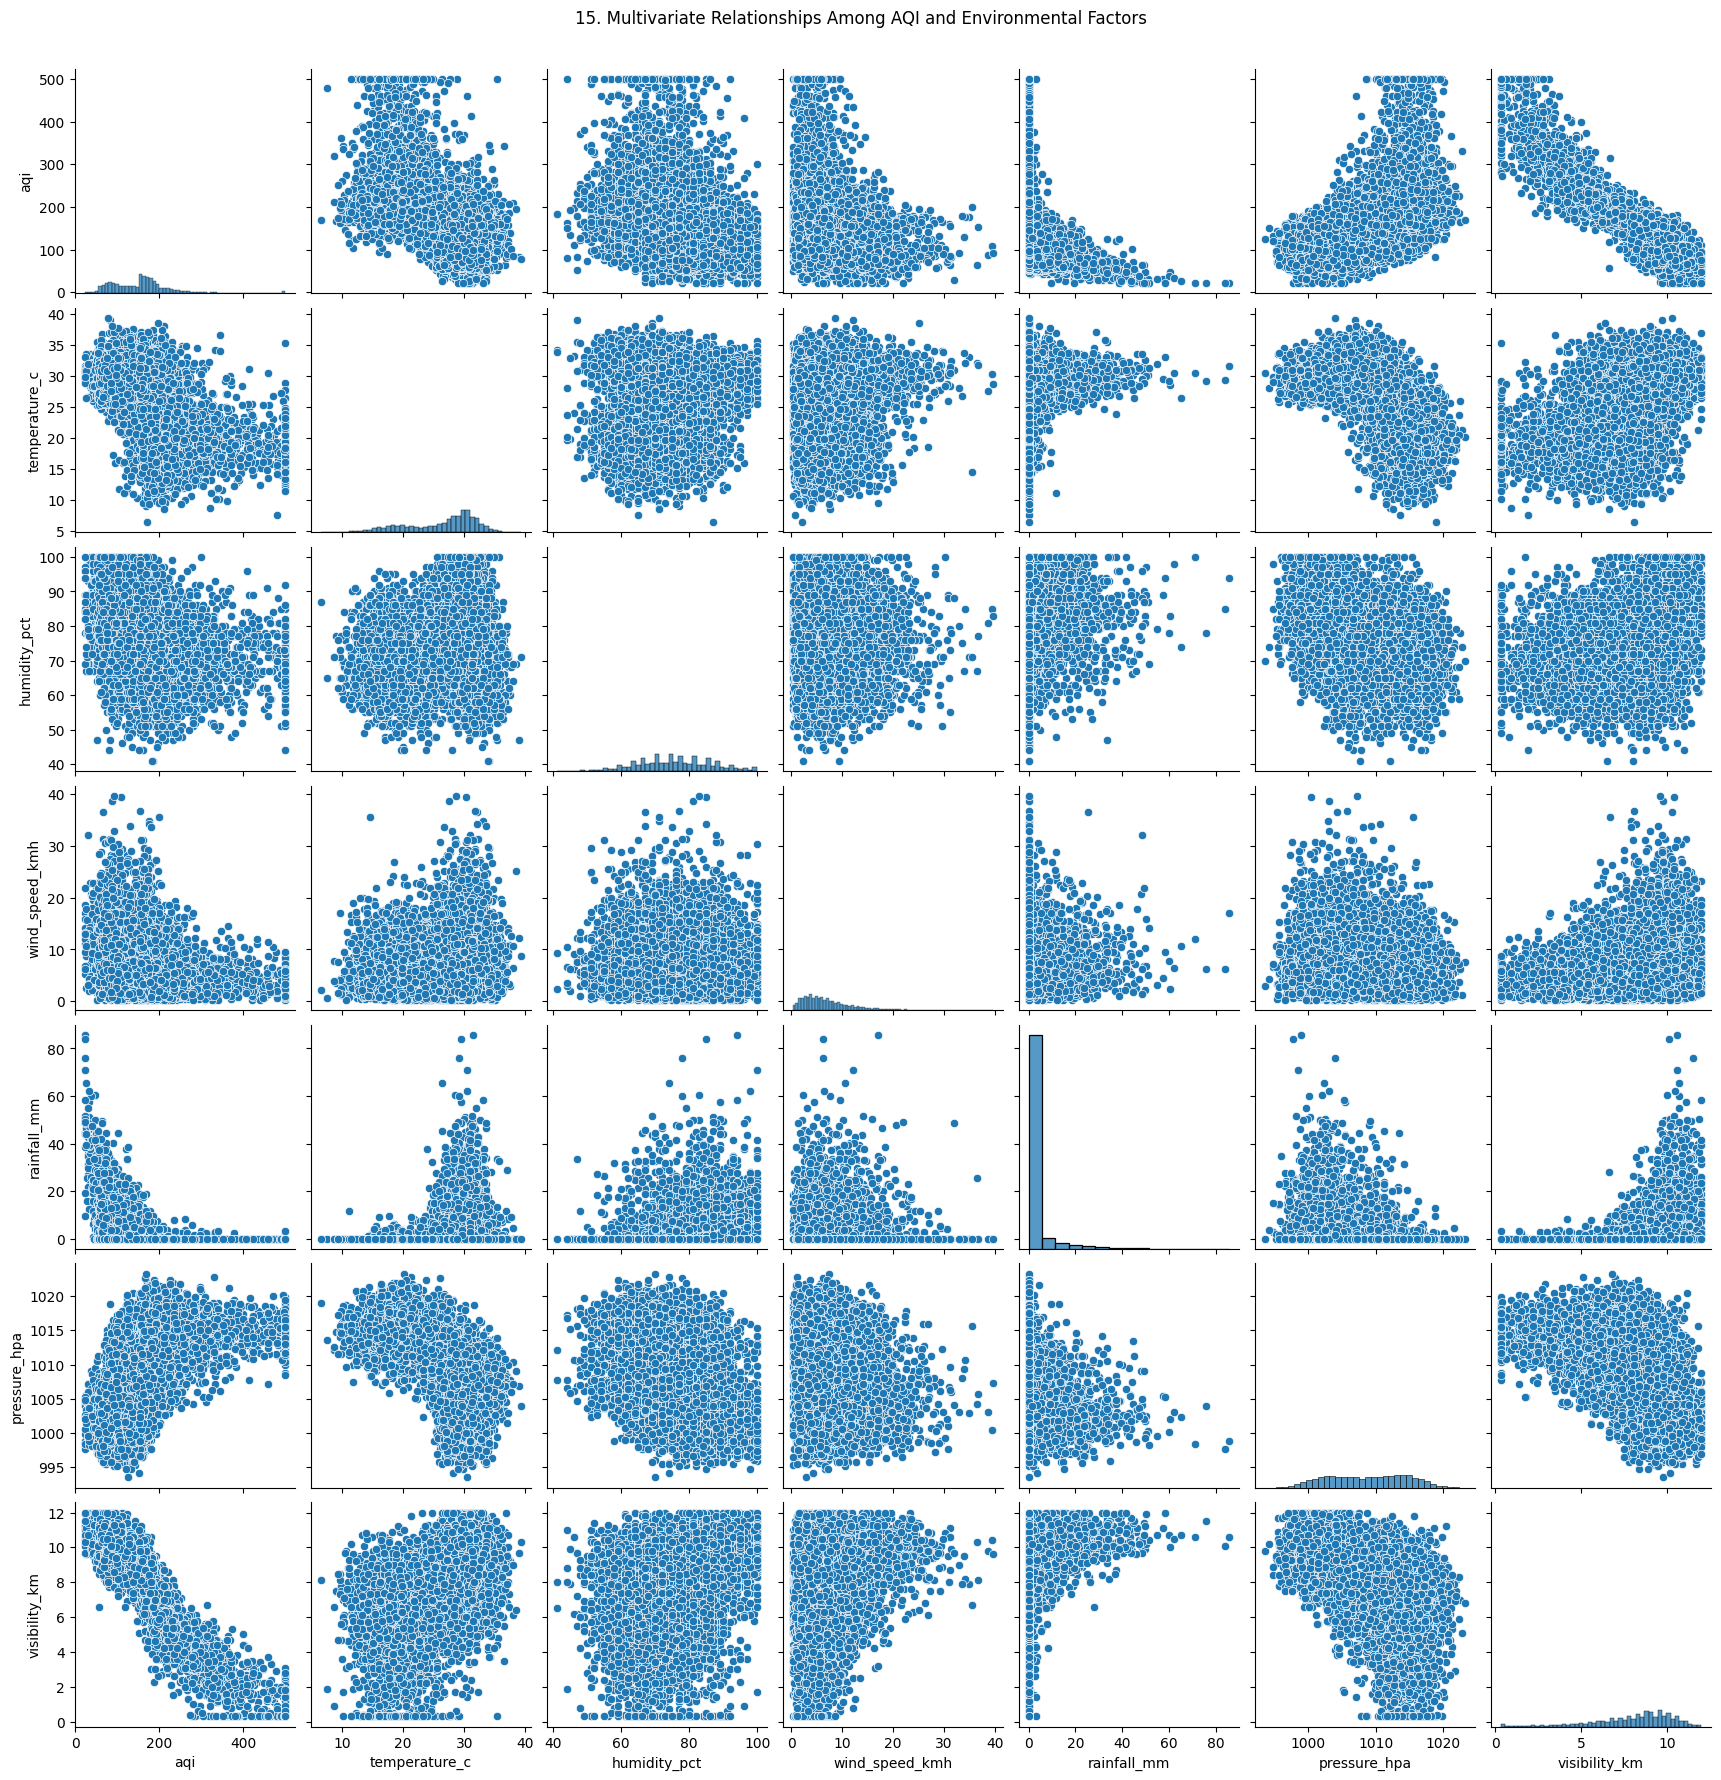

In [27]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['aqi', 'temperature_c', 'humidity_pct', 'wind_speed_kmh', 'rainfall_mm', 'pressure_hpa', 'visibility_km']])
plt.suptitle(f'{plot_no}. Multivariate Relationships Among AQI and Environmental Factors', y=1.02)
plt.show()
plot_no += 1

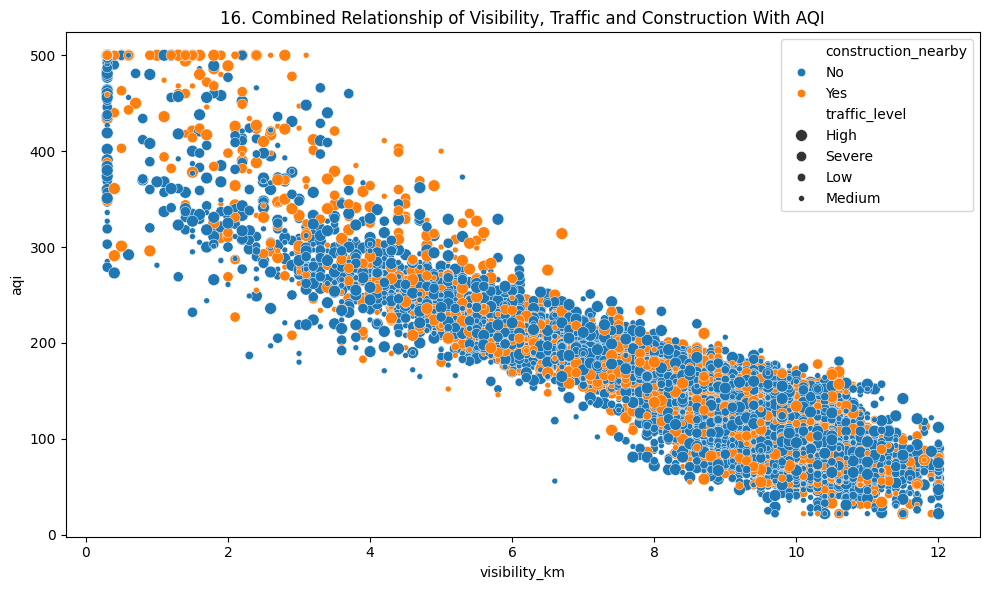

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='visibility_km', y='aqi', size='traffic_level', hue='construction_nearby')
plt.title(f'{plot_no}. Combined Relationship of Visibility, Traffic and Construction With AQI')
show_fig()
plot_no += 1

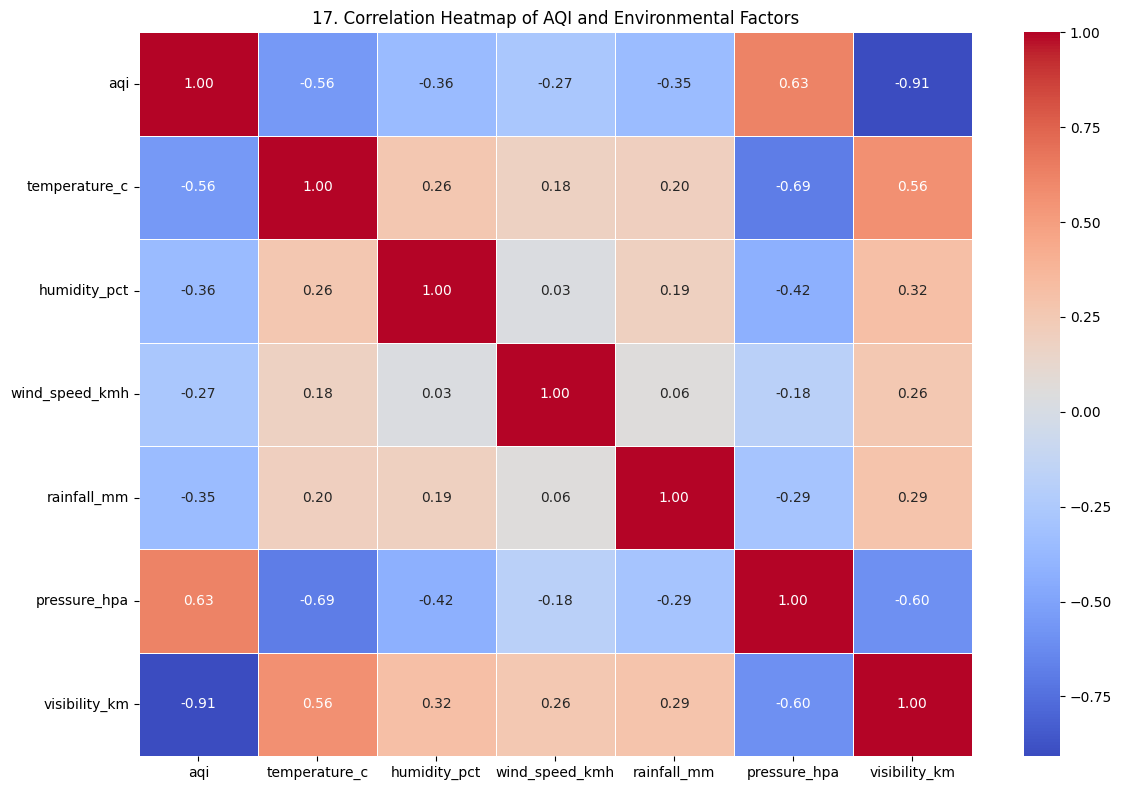

In [29]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of AQI and Environmental Factors')
show_fig()
plot_no += 1

# Model Training

## define target and features

In [30]:
target = 'aqi'
X = df.drop(columns=[target])
y = df[target]

## identify numerical and categorical features

In [31]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

## preprocess numerical and categorical features

In [32]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

## split dataset into training and testing sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## create gradient boosting regression model

In [34]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

## train the model

In [35]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## generate predictions

In [36]:
y_pred = model.predict(X_test)

## evaluate model performance

In [37]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9569
RMSE: 16.3866


## plot actual versus predicted AQI

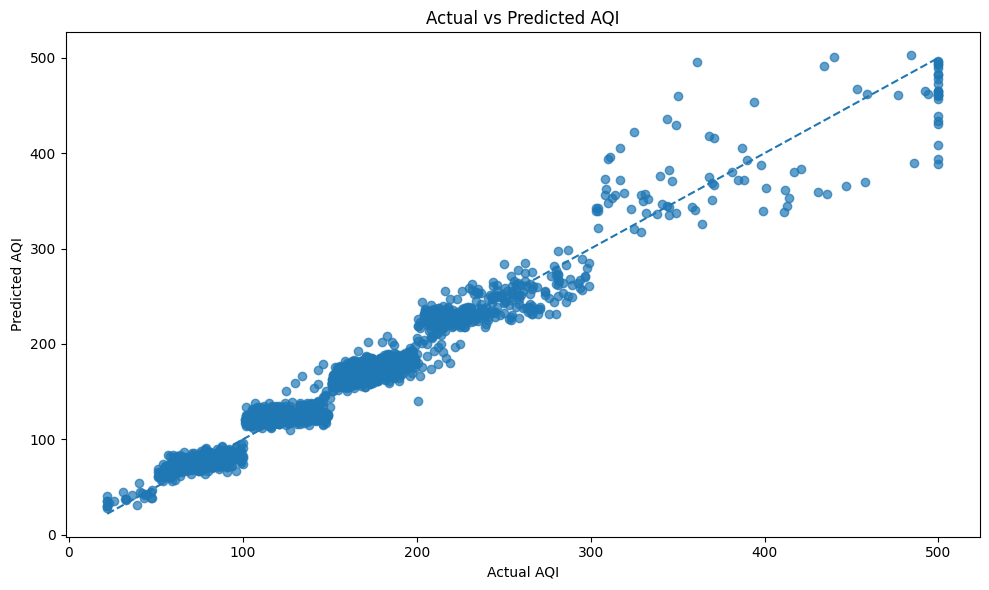

In [38]:
fig = plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI')
show_fig()
plot_no += 1